# Cross-Model Baseline — text-metric visualizations

Per-round text-similarity trajectories for the **cross-model baseline** (a MAIN model reads documents
synthesized from a SIDE model's answers; we measure the MAIN model via `run["answer"]`). Driven by the
`evaluation.py` outputs only — **no entity metrics** (`unique_entities` / `entity_similarity` /
collapse-by-simulation are entity-based and intentionally excluded here).

Each curve is a metric averaged across questions per round (shaded band = standard error of the mean).
Collapse reads as rising similarity / ROUGE / TES / same-answer% and falling unique-words over rounds.

**Extensible:** add eval files to `VARIANTS` below. The loader silently skips any that aren't present
yet, so when `replace_one` (or `search`) finishes and is downloaded, just re-run — it joins the plots
automatically.

In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# ── Config ──
# Local eval files downloaded from Unity (cross-model-baseline/ is gitignored).
EVAL_DIR = "cross-model-baseline/evaluation_outputs"
OUT_DIR  = "cross_model_baseline_visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

# label -> eval filename. Add/remove freely; missing files are skipped.
VARIANTS = {
    "Replace All": "local_replace_all_eval.json",
    "Replace One": "local_replace_one_eval.json",
    "Search":      "local_search_eval.json",
}

# colors match visualization.ipynb / agentic-rag-visualization.ipynb
COLORS = {
    "Replace All": "#1f77b4",
    "Replace One": "#ff7f0e",
    "Search":      "#2ca02c",
}

In [2]:
# ── Load whatever eval files are present ──
eval_data = {}
for label, fname in VARIANTS.items():
    path = os.path.join(EVAL_DIR, fname)
    if os.path.isfile(path):
        with open(path, "r", encoding="utf-8") as f:
            eval_data[label] = json.load(f)
        nq = len(eval_data[label]["questions"])
        nr = len(eval_data[label]["questions"][0]["iterations"]) if nq else 0
        print(f"loaded  {label:12s} <- {fname}  ({nq} questions, {nr} rounds)")
    else:
        print(f"skipped {label:12s} (not found: {path})")

assert eval_data, f"No eval files found under {EVAL_DIR}/"

loaded  Replace All  <- local_replace_all_eval.json  (400 questions, 10 rounds)


loaded  Replace One  <- local_replace_one_eval.json  (400 questions, 20 rounds)
skipped Search       (not found: cross-model-baseline/evaluation_outputs\local_search_eval.json)


In [3]:
# ── Aggregate a metric across questions, per round ──
def per_round(experiment, key):
    """Return (rounds, means, sems) for metric `key`, averaged across questions per round."""
    buckets = defaultdict(list)
    for q in experiment["questions"]:
        for it in q["iterations"]:
            m = it.get("metrics", {})
            v = m.get(key)
            if v is not None:
                buckets[it["iteration_number"]].append(v)
    rounds = sorted(buckets)
    means = np.array([np.mean(buckets[r]) for r in rounds])
    sems  = np.array([np.std(buckets[r]) / np.sqrt(len(buckets[r])) for r in rounds])
    return np.array(rounds), means, sems


# Metrics to plot: (json_key, title, y-axis label). Higher = more collapse, except unique_words.
METRICS = [
    ("avg_pairwise_similarity", "Cosine similarity across runs",  "avg pairwise cosine"),
    ("avg_pairwise_rougeL",     "ROUGE-L across runs",           "avg pairwise ROUGE-L"),
    ("avg_pairwise_tes",        "Token-edit similarity (TES)",   "avg pairwise TES"),
    ("same_answer_percentage",  "Same-answer % (LLM judge)",     "same-answer %"),
    ("unique_words",            "Unique words (round union)",    "unique words"),
    ("ai_reference_percentage", "AI-reference %",                "ai-reference %"),
]

wrote cross_model_baseline_visualizations\avg_pairwise_similarity_per_round.png


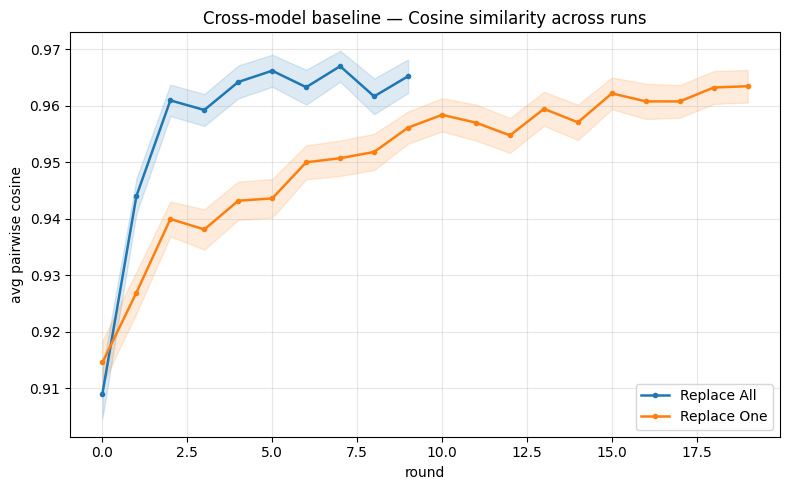

wrote cross_model_baseline_visualizations\avg_pairwise_rougeL_per_round.png


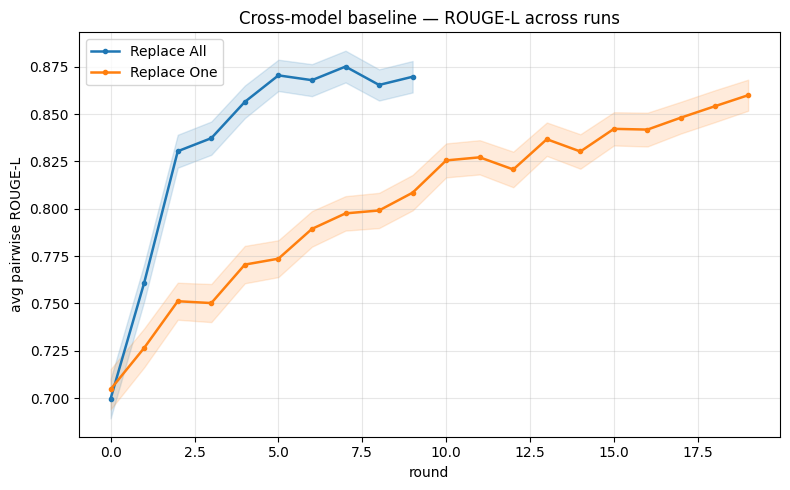

wrote cross_model_baseline_visualizations\avg_pairwise_tes_per_round.png


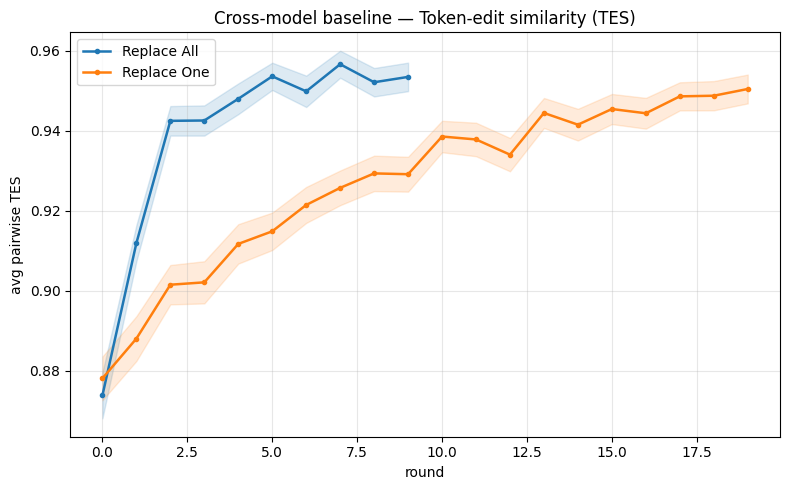

wrote cross_model_baseline_visualizations\same_answer_percentage_per_round.png


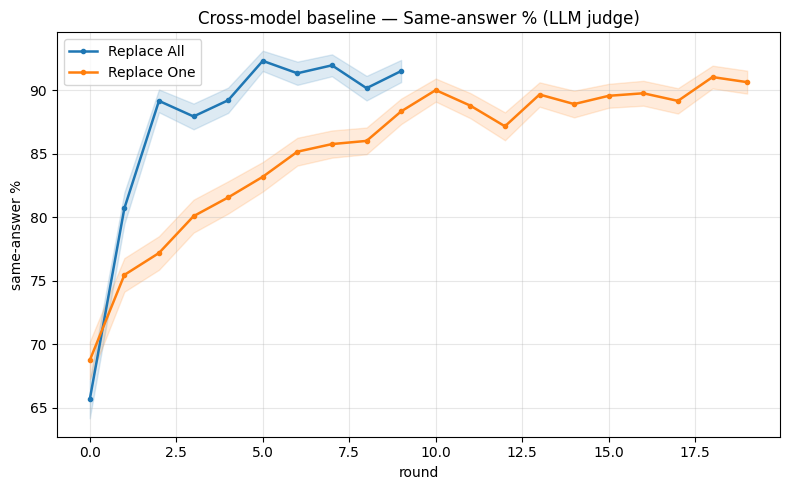

wrote cross_model_baseline_visualizations\unique_words_per_round.png


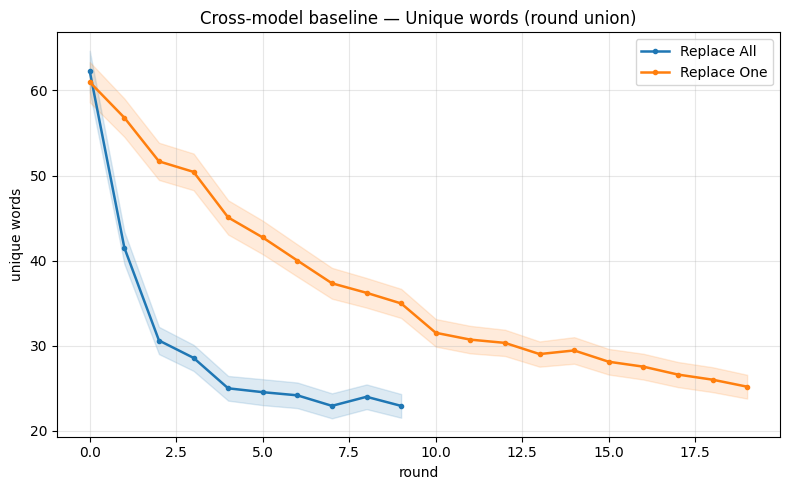

wrote cross_model_baseline_visualizations\ai_reference_percentage_per_round.png


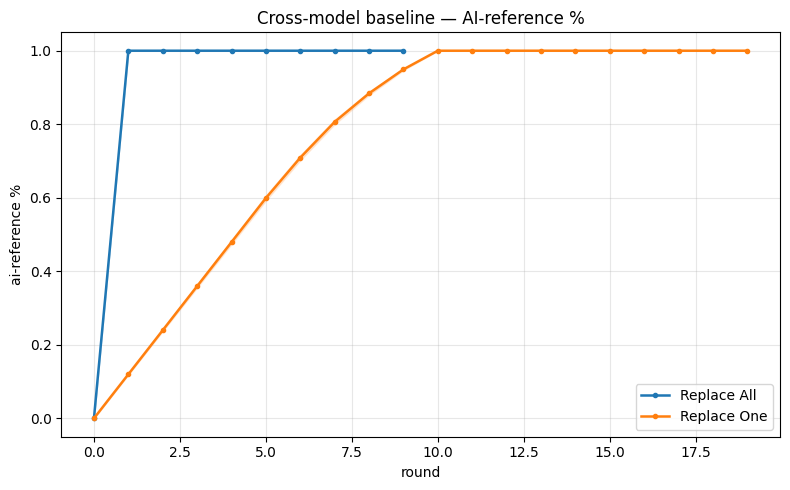

In [4]:
# ── One figure per metric (overlaid variants), saved to OUT_DIR ──
def plot_metric(key, title, ylabel, save=True):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, exp in eval_data.items():
        rounds, means, sems = per_round(exp, key)
        if len(rounds) == 0:
            continue
        c = COLORS.get(label)
        ax.plot(rounds, means, marker="o", ms=3, lw=1.8, color=c, label=label)
        ax.fill_between(rounds, means - sems, means + sems, color=c, alpha=0.15)
    ax.set_xlabel("round")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Cross-model baseline — {title}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if save:
        out = os.path.join(OUT_DIR, f"{key}_per_round.png")
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("wrote", out)
    plt.show()


for key, title, ylabel in METRICS:
    plot_metric(key, title, ylabel)

wrote cross_model_baseline_visualizations\all_metrics_per_round.png


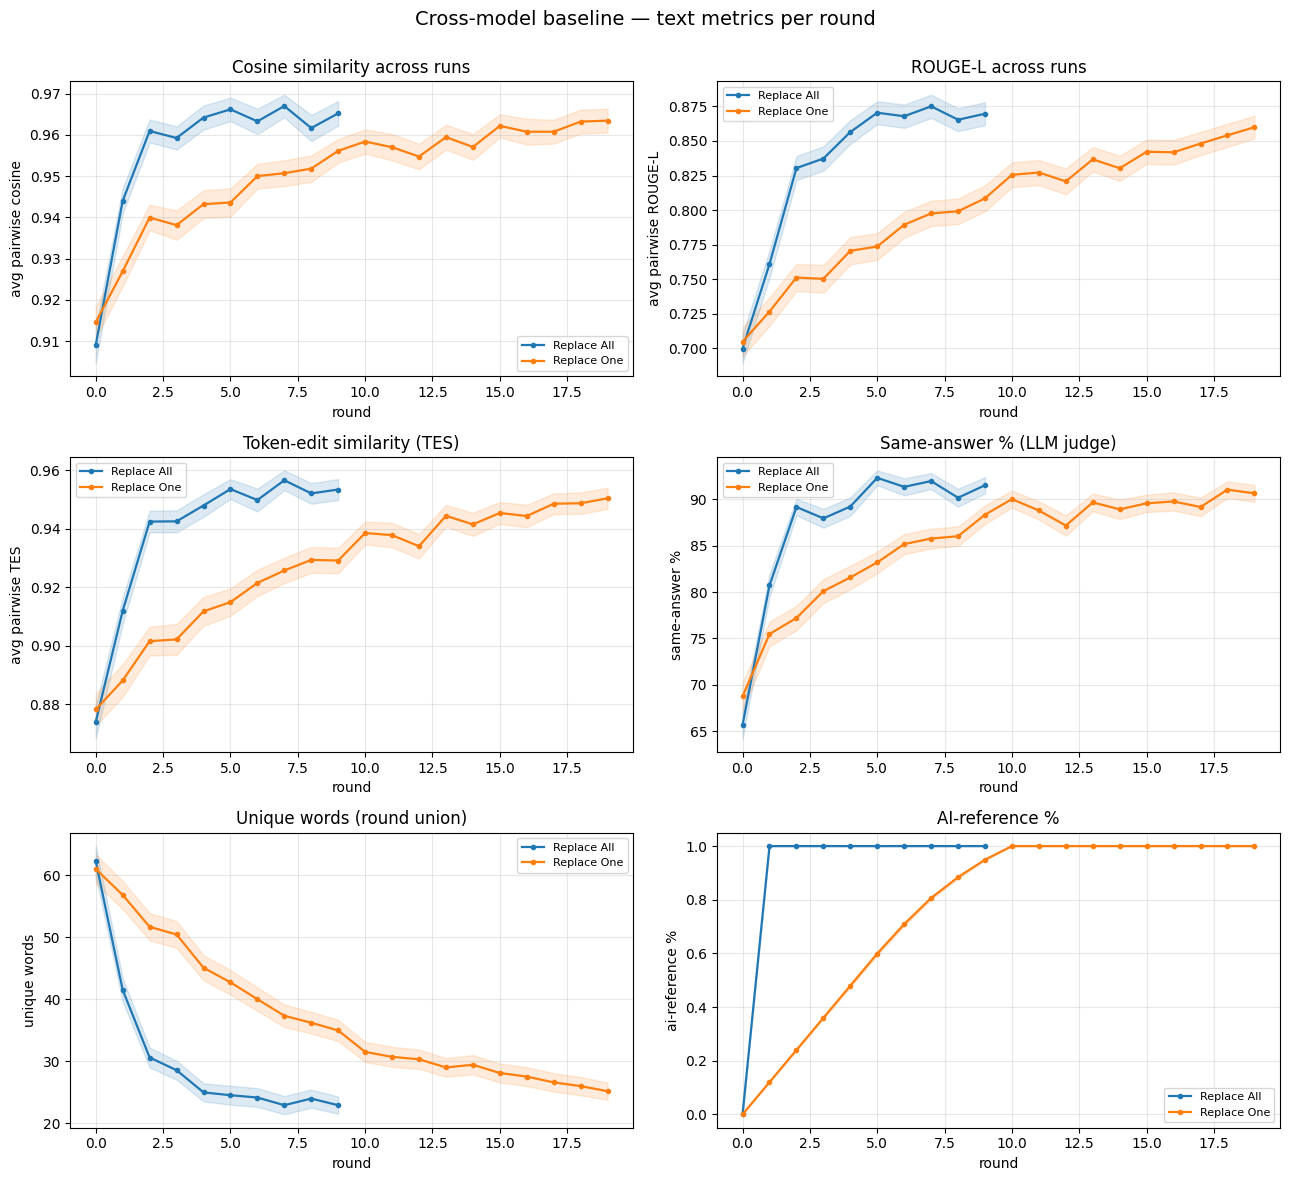

In [5]:
# ── Combined grid (all metrics in one figure) ──
ncol = 2
nrow = (len(METRICS) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4 * nrow))
axes = np.array(axes).reshape(-1)

for ax, (key, title, ylabel) in zip(axes, METRICS):
    for label, exp in eval_data.items():
        rounds, means, sems = per_round(exp, key)
        if len(rounds) == 0:
            continue
        c = COLORS.get(label)
        ax.plot(rounds, means, marker="o", ms=3, lw=1.6, color=c, label=label)
        ax.fill_between(rounds, means - sems, means + sems, color=c, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle("Cross-model baseline — text metrics per round", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
out = os.path.join(OUT_DIR, "all_metrics_per_round.png")
fig.savefig(out, dpi=150, bbox_inches="tight")
print("wrote", out)
plt.show()